# REAL TIME SIGN LANGUAGE TRANSLATOR

In [ ]:
# so basically i am making this for the convinience of mute people who are not priviliged enough and also for the sake of learning more about OpenCV and other python libraries . The ultimate goal is to make a project that detects the sign language and tells what it is saying through machine learning .

# BASICS U NEED TO LEARN -
First understand how sign language works. Many beginners think it is just hand gestures for letters, but real sign language is much richer. </br>
TYPES OF SIGNS =
1) Alphabet signs
2) Word gestures
3) Dynamic gestures
4) Grammar differences

## HAND TRACKING
DETECTS KEYPOINTS SUCH AS :     
wrist </br>
thumb_tip </br>
index_tip</br>
middle_tip</br>
ring_tip</br>
pinky_tip</br>

EACH KEYPOINT HAS - 3 COORDINATES
X , Y AND Z WHICH FURTHER BECOME OUR ML FEATURES






NOW LET US LOOK AT *THE CORE COMPONENTS* : </br>
1) OpenCV (The Eyes) :

OpenCV acts as your data pipeline. I*t captures the video feed from your webcam and prepares it for analysis.* However, passing a raw 1080p image directly into a neural network is slow. Usually, we use MediaPipe (which runs on top of OpenCV) to extract Landmarks.

**What it does:** Converts a video frame into a list of $x, y, z$ coordinates for 21 points on each hand.

Why it matters: It reduces the data from millions of pixels to just a few hundred numbers, making real-time processing possible even on a standard laptop.
</br>

2) LSTM in AIML (The Brain)

LSTM stands for *Long Short-Term Memory.* It is a type of Recurrent Neural Network (RNN) specifically designed to remember patterns in sequences.

**The Problem**: The sign for "Hello" and "Goodbye" might look similar in a single frame, but the direction of movement is what distinguishes them.

**The LSTM Solution:** It takes a sequence of frames (e.g., the last 30 frames) and analyzes the flow. It has "gates" that decide which previous movements are important to remember and which are "noise."
</br>

3) How the System Works (Architecture)

**Input**: OpenCV grabs a frame from the webcam.

**Feature Extraction**: MediaPipe identifies hand/body landmarks.

**Buffer**: You store these landmarks in a "window" (e.g., a list of the 30 most recent frames).

**Prediction**: The LSTM takes that 30-frame sequence and outputs a probability (e.g., 98% "Thank You").

**Output**: OpenCV overlays the text "Thank You" back onto the live video.

4) **MediaPipe** is a Google library that looks at a camera frame and says:

"I can see a hand. The tip of the index finger is at position (0.45, 0.32). The wrist is at (0.50, 0.80)..." and so on for all 21 points on the hand.

These 21 points are called landmarks. Each has an x, y, z coordinate = 63 numbers per hand, 126 for both hands.

**What Does "Training" Actually Mean Here?**

You're going to do this:
Recording phase (you do this once):

You sit in front of your camera
You sign "hello" 30 times
Each time you sign it, MediaPipe is secretly recording those 126 numbers, 30 times per second
Those numbers get saved to a file labeled "hello"
You repeat this for every word you want to teach

Training phase (computer does this):

The LSTM model looks at all your saved files
It tries to find patterns — "when the numbers look like THIS sequence, it's always labeled hello"
It adjusts itself thousands of times until it gets good at recognizing patterns
The result is a saved .h5 file — your trained model

In [ ]:
# SOURCES FROM WHERE I TRIED TO LEARN A BIT OF ASL ( AMERICAN SIGN LANGUAGE ):

# 1.https://www.signasl.org/  (this website has videos for words and sentences)
# 2. https://www.youtube.com/@LearnHowtoSign ( this youtube channel helped me learn a lot of stuff )

In [ ]:
!pip install mediapipe opencv-python numpy tensorflow

In [ ]:
!pip install mediapipe==0.10.13

In [ ]:
import cv2
import mediapipe as mp
import numpy as np

In [ ]:
# Setting up MediaPipe hands
mp_hands = mp.solutions.hands          # the hand detection model
mp_drawing = mp.solutions.drawing_utils  # tool to draw the dots on screen

# Just checking they loaded correctly
print("MediaPipe loaded successfully!")
print("mp_hands:", mp_hands)
print("mp_drawing:", mp_drawing)

MediaPipe loaded successfully!
mp_hands: <module 'mediapipe.python.solutions.hands' from '/usr/local/lib/python3.12/dist-packages/mediapipe/python/solutions/hands.py'>
mp_drawing: <module 'mediapipe.python.solutions.drawing_utils' from '/usr/local/lib/python3.12/dist-packages/mediapipe/python/solutions/drawing_utils.py'>


In [ ]:
from IPython.display import display, Javascript, Image
from google.colab.output import eval_js
from base64 import b64decode
import numpy as np
import cv2

# This function takes a single photo from your webcam
def take_photo():
    js = Javascript('''
        async function takePhoto() {
            const div = document.createElement('div');
            const capture = document.createElement('button');
            capture.textContent = 'Click here to capture photo';
            div.appendChild(capture);
            document.body.appendChild(div);

            const stream = await navigator.mediaDevices.getUserMedia({video: true});
            const video = document.createElement('video');
            video.srcObject = stream;
            await video.play();
            document.body.appendChild(video);

            await new Promise((resolve) => capture.onclick = resolve);

            const canvas = document.createElement('canvas');
            canvas.width = video.videoWidth;
            canvas.height = video.videoHeight;
            canvas.getContext('2d').drawImage(video, 0, 0);
            stream.getTracks().forEach(track => track.stop());

            return canvas.toDataURL('image/jpeg');
        }
        takePhoto()
    ''')
    display(js)
    data = eval_js('takePhoto()')
    binary = b64decode(data.split(',')[1])
    image = np.frombuffer(binary, dtype=np.uint8)
    return cv2.imdecode(image, cv2.IMREAD_COLOR)

print("Camera function ready!")

Camera function ready!


<IPython.core.display.Javascript object>

Photo captured!
Hand detected!
Number of hands found: 1


/usr/local/lib/python3.12/dist-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


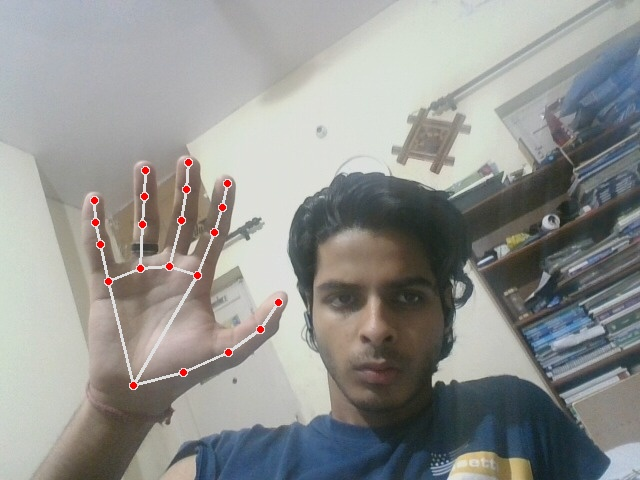

In [ ]:
# Step 1 — Take a photo from your webcam
# A button will appear below — show your hand to camera then click it
image = take_photo()
print("Photo captured!")

# Step 2 — MediaPipe needs the image in RGB format (camera gives BGR by default)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Step 3 — Create the hand detector and process the image
with mp_hands.Hands() as hands:
    results = hands.process(image_rgb)

# Step 4 — Check if MediaPipe found a hand
if results.multi_hand_landmarks:
    print("Hand detected!")
    print("Number of hands found:", len(results.multi_hand_landmarks))
else:
    print("No hand detected — try again with your hand clearly visible")

# Step 5 — Draw the dots on your hand and show the image
if results.multi_hand_landmarks:
    for hand_landmarks in results.multi_hand_landmarks:
        mp_drawing.draw_landmarks(image, hand_landmarks, mp_hands.HAND_CONNECTIONS)

# Show the image with dots drawn on it
_, buffer = cv2.imencode('.jpg', image)
display(Image(data=buffer.tobytes()))

In [ ]:
with mp_hands.Hands() as hands:
    results = hands.process(image_rgb)

In [ ]:
if results.multi_hand_landmarks:
    # Get the first hand it found
    hand = results.multi_hand_landmarks[0]

    # Loop through all 21 dots and print their coordinates
    for i, landmark in enumerate(hand.landmark):
        print(f"Dot {i} → x: {round(landmark.x, 3)},  y: {round(landmark.y, 3)},  z: {round(landmark.z, 3)}")

Dot 0 → x: 0.209,  y: 0.803,  z: 0.0
Dot 1 → x: 0.287,  y: 0.775,  z: -0.037
Dot 2 → x: 0.357,  y: 0.734,  z: -0.051
Dot 3 → x: 0.407,  y: 0.687,  z: -0.061
Dot 4 → x: 0.435,  y: 0.631,  z: -0.07
Dot 5 → x: 0.309,  y: 0.574,  z: -0.007
Dot 6 → x: 0.335,  y: 0.484,  z: -0.012
Dot 7 → x: 0.348,  y: 0.431,  z: -0.023
Dot 8 → x: 0.355,  y: 0.382,  z: -0.034
Dot 9 → x: 0.265,  y: 0.555,  z: -0.004
Dot 10 → x: 0.284,  y: 0.46,  z: -0.007
Dot 11 → x: 0.292,  y: 0.394,  z: -0.024
Dot 12 → x: 0.295,  y: 0.339,  z: -0.04
Dot 13 → x: 0.219,  y: 0.56,  z: -0.006
Dot 14 → x: 0.223,  y: 0.467,  z: -0.014
Dot 15 → x: 0.226,  y: 0.408,  z: -0.032
Dot 16 → x: 0.228,  y: 0.356,  z: -0.047
Dot 17 → x: 0.169,  y: 0.586,  z: -0.012
Dot 18 → x: 0.157,  y: 0.509,  z: -0.025
Dot 19 → x: 0.149,  y: 0.464,  z: -0.034
Dot 20 → x: 0.147,  y: 0.417,  z: -0.042


In [ ]:
# Let's convert those 21 dots into a flat numpy array
with mp_hands.Hands() as hands:
    results = hands.process(image_rgb)

if results.multi_hand_landmarks:
    hand = results.multi_hand_landmarks[0]

    # Extract x, y, z from each dot and flatten into one long array
    landmarks = []
    for landmark in hand.landmark:
        landmarks.append(landmark.x)
        landmarks.append(landmark.y)
        landmarks.append(landmark.z)

    # Convert to numpy array
    landmarks = np.array(landmarks)

    print("Shape:", landmarks.shape)   # should print (63,)
    print("First 10 values:", landmarks[:10])

Shape: (63,)
First 10 values: [ 2.08730027e-01  8.02520156e-01  7.95232665e-07  2.87178665e-01
  7.75392771e-01 -3.70148718e-02  3.56759220e-01  7.33912110e-01
 -5.10434248e-02  4.06594962e-01]


In [ ]:
def get_landmarks(results):
    # Start with 126 zeros (two hands worth of empty data)
    landmarks = np.zeros(126)

    if results.multi_hand_landmarks:
        for i, hand in enumerate(results.multi_hand_landmarks):
            if i > 1:  # only process max 2 hands
                break
            # Fill in the landmarks for this hand (63 numbers per hand)
            for j, landmark in enumerate(hand.landmark):
                landmarks[i*63 + j*3]     = landmark.x
                landmarks[i*63 + j*3 + 1] = landmark.y
                landmarks[i*63 + j*3 + 2] = landmark.z

    return landmarks

# Test it with our existing image
with mp_hands.Hands() as hands:
    results = hands.process(image_rgb)

landmarks = get_landmarks(results)
print("Shape:", landmarks.shape)   # should always be (126,)
print("First 10 values:", landmarks[:10])

Shape: (126,)
First 10 values: [ 2.08730027e-01  8.02520156e-01  7.95232665e-07  2.87178665e-01
  7.75392771e-01 -3.70148718e-02  3.56759220e-01  7.33912110e-01
 -5.10434248e-02  4.06594962e-01]


In [ ]:
# How many frames we want per sample
FRAMES_PER_SAMPLE = 30

# Take 30 photos and collect landmarks from each
one_sample = []

print("Get ready to sign! Take 30 photos one by one...")
print("Keep your hand in the same sign for all 30 photos\n")

with mp_hands.Hands() as hands:
    for i in range(FRAMES_PER_SAMPLE):
        print(f"Photo {i+1} of {FRAMES_PER_SAMPLE} — click the button")

        # Take photo
        image = take_photo()
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Get landmarks
        results = hands.process(image_rgb)
        landmarks = get_landmarks(results)

        # Add to our sample
        one_sample.append(landmarks)

# Stack all 30 frames into one numpy array
one_sample = np.array(one_sample)
print("\nDone!")
print("Shape of one sample:", one_sample.shape)  # should be (30, 126)

Get ready to sign! Take 30 photos one by one...
Keep your hand in the same sign for all 30 photos

Photo 1 of 30 — click the button


<IPython.core.display.Javascript object>

Photo 2 of 30 — click the button


<IPython.core.display.Javascript object>

Photo 3 of 30 — click the button


...

Photo 29 of 30 — click the button


<IPython.core.display.Javascript object>

Photo 30 of 30 — click the button


<IPython.core.display.Javascript object>


Done!
Shape of one sample: (30, 126)


In [ ]:
import os

# Your 5 signs
SIGNS = ['hello', 'yes', 'thank you', 'i love you', 'please']

# 30 recordings per sign
NO_OF_RECORDINGS = 30

# 30 frames per recording
FRAMES_PER_SAMPLE = 30

# Create folders to save data
# Structure: data/hello/0, data/hello/1 ... data/hello/29
for sign in SIGNS:
    for recording in range(NO_OF_RECORDINGS):
        os.makedirs(f'data/{sign}/{recording}', exist_ok=True)

print("Folders created!")
print(f"Total recordings to collect: {len(SIGNS) * NO_OF_RECORDINGS}")
print(f"That is {len(SIGNS)} signs × {NO_OF_RECORDINGS} recordings each")

Folders created!
Total recordings to collect: 150
That is 5 signs × 30 recordings each


In [ ]:
# COLLECT DATA FOR ALL SIGNS
with mp_hands.Hands() as hands:
    for sign in SIGNS:
        for recording in range(NO_OF_RECORDINGS):

            print(f"\n{'='*40}")
            print(f"📝 Sign: {sign.upper()}")
            print(f"🎬 Recording: {recording + 1} of {NO_OF_RECORDINGS}")
            print(f"{'='*40}")

            for frame in range(FRAMES_PER_SAMPLE):
                print(f"Frame {frame+1}/{FRAMES_PER_SAMPLE} — show '{sign}' and click!")

                # Take photo
                image = take_photo()
                image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

                # Get landmarks
                results = hands.process(image_rgb)
                landmarks = get_landmarks(results)

                # Save this frame as .npy file
                np.save(f'data/{sign}/{recording}/{frame}.npy', landmarks)

            print(f"✅ Recording {recording+1} of '{sign}' saved!")

        print(f"\n🎉 '{sign}' fully done!")

print("\n✅ ALL DATA COLLECTED SUCCESSFULLY!")


📝 Sign: HELLO
🎬 Recording: 1 of 30
Frame 1/30 — show 'hello' and click!


<IPython.core.display.Javascript object>

Frame 2/30 — show 'hello' and click!


<IPython.core.display.Javascript object>

Frame 3/30 — show 'hello' and click!


...

Frame 10/30 — show 'hello' and click!


<IPython.core.display.Javascript object>

Frame 11/30 — show 'hello' and click!


<IPython.core.display.Javascript object>

KeyboardInterrupt: 

In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"harshpratapsingh777","key":"792cb840b47f534b56d2fe7b816a1201"}'}

In [2]:
import os
# Move kaggle.json to the right folder
os.makedirs('/root/.kaggle', exist_ok=True)
os.rename('kaggle.json', '/root/.kaggle/kaggle.json')

# Fix permissions (Kaggle requires this)
os.chmod('/root/.kaggle/kaggle.json', 600)

print("Kaggle setup done!")

Kaggle setup done!


In [3]:
!kaggle datasets download -d risangbaskoro/wlasl-processed

Dataset URL: https://www.kaggle.com/datasets/risangbaskoro/wlasl-processed
License(s): other
100% 4.82G/4.82G [00:56<00:00, 249MB/s]
100% 4.82G/4.82G [00:56<00:00, 91.2MB/s]


In [4]:
# Unzip the downloaded file
import zipfile

print("Unzipping... this may take a few minutes...")

with zipfile.ZipFile('wlasl-processed.zip', 'r') as zip_ref:
    zip_ref.extractall('wlasl_data')

print("Done! Let's see what's inside:")

# See what we got
import os
for item in os.listdir('wlasl_data'):
    print(item)

Unzipping... this may take a few minutes...
Done! Let's see what's inside:
missing.txt
nslt_2000.json
nslt_1000.json
videos
nslt_300.json
nslt_100.json
WLASL_v0.3.json
wlasl_class_list.txt


In [5]:
import json

# Let's look at the class list first - these are all the signs available
with open('wlasl_data/wlasl_class_list.txt', 'r') as f:
    classes = f.read().splitlines()

print(f"Total signs available: {len(classes)}")
print("\nFirst 20 signs:")
for i, c in enumerate(classes[:20]):
    print(f"{i}: {c}")

Total signs available: 2000

First 20 signs:
0: 0	book
1: 1	drink
2: 2	computer
3: 3	before
4: 4	chair
5: 5	go
6: 6	clothes
7: 7	who
8: 8	candy
9: 9	cousin
10: 10	deaf
11: 11	fine
12: 12	help
13: 13	no
14: 14	thin
15: 15	walk
16: 16	year
17: 17	yes
18: 18	all
19: 19	black


In [6]:
# Check if our signs exist in the dataset
our_signs = ['hello', 'yes', 'thank you', 'please', 'i love you']

print("Checking our signs:")
for sign in our_signs:
    if sign in classes:
        index = classes.index(sign)
        print(f"✅ '{sign}' found at index {index}")
    else:
        print(f"❌ '{sign}' NOT found")

Checking our signs:
❌ 'hello' NOT found
❌ 'yes' NOT found
❌ 'thank you' NOT found
❌ 'please' NOT found
❌ 'i love you' NOT found


In [7]:
# Fix - strip whitespace and tabs from class names
classes_clean = [c.strip().split('\t')[-1].strip() for c in classes]

print("First 20 cleaned signs:")
for i, c in enumerate(classes_clean[:20]):
    print(f"{i}: {c}")

print("\nChecking our signs:")
our_signs = ['hello', 'yes', 'thank you', 'please', 'i love you']
for sign in our_signs:
    if sign in classes_clean:
        index = classes_clean.index(sign)
        print(f"✅ '{sign}' found at index {index}")
    else:
        print(f"❌ '{sign}' NOT found")

First 20 cleaned signs:
0: book
1: drink
2: computer
3: before
4: chair
5: go
6: clothes
7: who
8: candy
9: cousin
10: deaf
11: fine
12: help
13: no
14: thin
15: walk
16: year
17: yes
18: all
19: black

Checking our signs:
✅ 'hello' found at index 402
✅ 'yes' found at index 17
✅ 'thank you' found at index 333
✅ 'please' found at index 234
❌ 'i love you' NOT found


In [8]:
# Search for similar signs
search_terms = ['love', 'i love', 'iloveyou']

for term in search_terms:
    matches = [c for c in classes_clean if term in c.lower()]
    print(f"'{term}' matches: {matches}")

'love' matches: ['love', 'gloves', 'fall in love']
'i love' matches: []
'iloveyou' matches: []


In [9]:
# Our final 5 signs
SIGNS = ['hello', 'yes', 'thank you', 'please', 'love']

print("Final signs and their indexes:")
for sign in SIGNS:
    index = classes_clean.index(sign)
    print(f"✅ '{sign}' → index {index}")

Final signs and their indexes:
✅ 'hello' → index 402
✅ 'yes' → index 17
✅ 'thank you' → index 333
✅ 'please' → index 234
✅ 'love' → index 561


In [10]:
# Let's see how the videos folder is organized
video_folder = 'wlasl_data/videos'

# Count total videos
all_videos = os.listdir(video_folder)
print(f"Total videos available: {len(all_videos)}")
print("\nFirst 5 video filenames:")
for v in all_videos[:5]:
    print(v)

Total videos available: 11980

First 5 video filenames:
66222.mp4
35928.mp4
04073.mp4
63668.mp4
02718.mp4


In [11]:
# Load the main JSON file which maps signs to video IDs
with open('wlasl_data/WLASL_v0.3.json', 'r') as f:
    wlasl_data = json.load(f)

# Find videos for our 5 signs
sign_videos = {}

for entry in wlasl_data:
    word = entry['gloss']  # the sign name
    if word in SIGNS:
        videos = []
        for instance in entry['instances']:
            video_id = str(instance['video_id']).zfill(5)  # e.g. 66222
            video_path = f'wlasl_data/videos/{video_id}.mp4'
            if os.path.exists(video_path):  # only add if video actually exists
                videos.append(video_path)
        sign_videos[word] = videos
        print(f"✅ '{word}' → {len(videos)} videos found")

print(f"\nTotal videos to process: {sum(len(v) for v in sign_videos.values())}")

✅ 'yes' → 12 videos found
✅ 'please' → 7 videos found
✅ 'thank you' → 7 videos found
✅ 'hello' → 4 videos found
✅ 'love' → 7 videos found

Total videos to process: 37


In [12]:
# Load the main JSON file which maps signs to video IDs
with open('wlasl_data/WLASL_v0.3.json', 'r') as f:
    wlasl_data = json.load(f)

# Find videos for our 5 signs
sign_videos = {}

for entry in wlasl_data:
    word = entry['gloss']  # the sign name
    if word in SIGNS:
        videos = []
        for instance in entry['instances']:
            video_id = str(instance['video_id']).zfill(5)  # e.g. 66222
            video_path = f'wlasl_data/videos/{video_id}.mp4'
            if os.path.exists(video_path):  # only add if video actually exists
                videos.append(video_path)
        sign_videos[word] = videos
        print(f"✅ '{word}' → {len(videos)} videos found")

print(f"\nTotal videos to process: {sum(len(v) for v in sign_videos.values())}")

✅ 'yes' → 12 videos found
✅ 'please' → 7 videos found
✅ 'thank you' → 7 videos found
✅ 'hello' → 4 videos found
✅ 'love' → 7 videos found

Total videos to process: 37


In [14]:
import cv2
import mediapipe as mp
import numpy as np
import os
import json

# Reload MediaPipe
mp_hands = mp.solutions.hands
mp_drawing = mp.solutions.drawing_utils

# Reload our functions and variables
SIGNS = ['hello', 'yes', 'thank you', 'please', 'love']
FRAMES_PER_SAMPLE = 30

def get_landmarks(results):
    landmarks = np.zeros(126)
    if results.multi_hand_landmarks:
        for i, hand in enumerate(results.multi_hand_landmarks):
            if i > 1:
                break
            for j, landmark in enumerate(hand.landmark):
                landmarks[i*63 + j*3]     = landmark.x
                landmarks[i*63 + j*3 + 1] = landmark.y
                landmarks[i*63 + j*3 + 2] = landmark.z
    return landmarks

print("Everything reloaded!")

ModuleNotFoundError: No module named 'mediapipe'

In [15]:
!pip install mediapipe==0.10.13 opencv-python numpy tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.6/35.6 MB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 18.8 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grain 0.2.16 requires protobuf>=5.28.3, but you have protobuf 4.25.8 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 4.25.8 which is incompatible.
opentelemetry-proto 1.38.0 requires protobuf<7.0,>=5.0, but you have protobuf 4.25.8 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 4.25.8 which is incompatible.


In [1]:
import cv2
import mediapipe as mp
import numpy as np
import os
import json

mp_hands = mp.solutions.hands
mp_drawing = mp.solutions.drawing_utils

print("Done!")

Done!


In [2]:
SIGNS = ['hello', 'yes', 'thank you', 'please', 'love']
FRAMES_PER_SAMPLE = 30

def get_landmarks(results):
    landmarks = np.zeros(126)
    if results.multi_hand_landmarks:
        for i, hand in enumerate(results.multi_hand_landmarks):
            if i > 1:
                break
            for j, landmark in enumerate(hand.landmark):
                landmarks[i*63 + j*3]     = landmark.x
                landmarks[i*63 + j*3 + 1] = landmark.y
                landmarks[i*63 + j*3 + 2] = landmark.z
    return landmarks

print("Done!")

Done!


In [3]:
with open('wlasl_data/WLASL_v0.3.json', 'r') as f:
    wlasl_data = json.load(f)

classes_clean = []
with open('wlasl_data/wlasl_class_list.txt', 'r') as f:
    classes = f.read().splitlines()
    classes_clean = [c.strip().split('\t')[-1].strip() for c in classes]

sign_videos = {}
for entry in wlasl_data:
    word = entry['gloss']
    if word in SIGNS:
        videos = []
        for instance in entry['instances']:
            video_id = str(instance['video_id']).zfill(5)
            video_path = f'wlasl_data/videos/{video_id}.mp4'
            if os.path.exists(video_path):
                videos.append(video_path)
        sign_videos[word] = videos
        print(f"✅ '{word}' → {len(videos)} videos found")

✅ 'yes' → 12 videos found
✅ 'please' → 7 videos found
✅ 'thank you' → 7 videos found
✅ 'hello' → 4 videos found
✅ 'love' → 7 videos found


In [4]:
# Create output folders
for sign in SIGNS:
    for i in range(len(sign_videos[sign])):
        os.makedirs(f'data/{sign}/{i}', exist_ok=True)

print("Processing videos...")

with mp_hands.Hands(static_image_mode=False, max_num_hands=2) as hands:
    for sign, videos in sign_videos.items():
        print(f"\n Processing '{sign}'...")

        for vid_idx, video_path in enumerate(videos):
            cap = cv2.VideoCapture(video_path)
            total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

            # Pick 30 evenly spaced frames from the video
            frame_indices = np.linspace(0, total_frames-1, FRAMES_PER_SAMPLE, dtype=int)

            collected = []
            frame_num = 0

            while True:
                ret, frame = cap.read()
                if not ret:
                    break

                if frame_num in frame_indices:
                    image_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                    results = hands.process(image_rgb)
                    landmarks = get_landmarks(results)
                    collected.append(landmarks)

                frame_num += 1

            cap.release()

            # Pad or trim to exactly 30 frames
            while len(collected) < FRAMES_PER_SAMPLE:
                collected.append(np.zeros(126))
            collected = collected[:FRAMES_PER_SAMPLE]

            # Save each frame
            for frame_idx, lm in enumerate(collected):
                np.save(f'data/{sign}/{vid_idx}/{frame_idx}.npy', lm)

            print(f"  ✅ Video {vid_idx+1}/{len(videos)} done")

print("\n✅ ALL VIDEOS PROCESSED!")

Processing videos...

 Processing 'yes'...


/usr/local/lib/python3.12/dist-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


  ✅ Video 1/12 done
  ✅ Video 2/12 done
  ✅ Video 3/12 done
  ✅ Video 4/12 done
  ✅ Video 5/12 done
  ✅ Video 6/12 done
  ✅ Video 7/12 done
  ✅ Video 8/12 done
  ✅ Video 9/12 done
  ✅ Video 10/12 done
  ✅ Video 11/12 done
  ✅ Video 12/12 done

 Processing 'please'...
  ✅ Video 1/7 done
  ✅ Video 2/7 done
  ✅ Video 3/7 done
  ✅ Video 4/7 done
  ✅ Video 5/7 done
  ✅ Video 6/7 done
  ✅ Video 7/7 done

 Processing 'thank you'...
  ✅ Video 1/7 done
  ✅ Video 2/7 done
  ✅ Video 3/7 done
  ✅ Video 4/7 done
  ✅ Video 5/7 done
  ✅ Video 6/7 done
  ✅ Video 7/7 done

 Processing 'hello'...
  ✅ Video 1/4 done
  ✅ Video 2/4 done
  ✅ Video 3/4 done
  ✅ Video 4/4 done

 Processing 'love'...
  ✅ Video 1/7 done
  ✅ Video 2/7 done
  ✅ Video 3/7 done
  ✅ Video 4/7 done
  ✅ Video 5/7 done
  ✅ Video 6/7 done
  ✅ Video 7/7 done

✅ ALL VIDEOS PROCESSED!


In [5]:
# Check our data folder
print("Checking saved data...\n")

for sign in SIGNS:
    total_frames = 0
    recordings = os.listdir(f'data/{sign}')
    for recording in recordings:
        frames = os.listdir(f'data/{sign}/{recording}')
        total_frames += len(frames)
    print(f"✅ '{sign}' → {len(recordings)} recordings, {total_frames} total frames")

Checking saved data...

✅ 'hello' → 4 recordings, 120 total frames
✅ 'yes' → 12 recordings, 360 total frames
✅ 'thank you' → 7 recordings, 210 total frames
✅ 'please' → 7 recordings, 210 total frames
✅ 'love' → 7 recordings, 210 total frames
